In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import folium
import os
import matplotlib.colors as mcolors
import matplotlib.cm as cm


In [2]:
# Load the datasets
rai_df = pd.read_csv('rai_impact_grid.csv')
asset_df = pd.read_csv('LitPop_pc_30arcsec_PHL.csv')


In [3]:
# Convert to GeoDataFrames
rai_gdf = gpd.GeoDataFrame(
    rai_df,
    geometry=[Point(xy) for xy in zip(rai_df.longitude, rai_df.latitude)],
    crs="EPSG:4326"
)
asset_gdf = gpd.GeoDataFrame(
    asset_df,
    geometry=[Point(xy) for xy in zip(asset_df.longitude, asset_df.latitude)],
    crs="EPSG:4326"
)


In [4]:
asset_gdf

,value,latitude,longitude,region_id,geometry
0,365.331980,8.054167,116.962500,608,POINT (116.9625 8.05417)
1,2320.983172,8.045833,116.962500,608,POINT (116.9625 8.04583)
2,3336.471193,8.037500,116.962500,608,POINT (116.9625 8.0375)
3,3517.351404,8.029167,116.962500,608,POINT (116.9625 8.02917)
4,4122.624744,8.020833,116.962500,608,POINT (116.9625 8.02083)
...,...,...,...,...,...
350896,47.557653,7.270833,126.604167,608,POINT (126.60417 7.27083)
350897,0.000000,7.262500,126.604167,608,POINT (126.60417 7.2625)
350898,0.000000,7.254167,126.604167,608,POINT (126.60417 7.25417)
350899,0.000000,7.270833,126.612500,608,POINT (126.6125 7.27083)


In [5]:
rai_gdf

,longitude,latitude,time,quadrant,wind_radius_nm,geometry
0,126.800003,9.800000,2021-12-16 03:00:00,USA_R64_NE,60.0,POINT (126.8 9.8)
1,127.800003,9.800000,2021-12-16 03:00:00,USA_R64_NE,60.0,POINT (127.8 9.8)
2,126.800003,10.800000,2021-12-16 03:00:00,USA_R64_NE,60.0,POINT (126.8 10.8)
3,127.800003,10.800000,2021-12-16 03:00:00,USA_R64_NE,60.0,POINT (127.8 10.8)
4,126.800003,9.800000,2021-12-16 03:00:00,USA_R64_SE,73.0,POINT (126.8 9.8)
...,...,...,...,...,...,...
203,117.250000,9.750000,2021-12-17 15:00:00,USA_R64_SW,45.0,POINT (117.25 9.75)
204,118.000000,10.500000,2021-12-17 15:00:00,USA_R64_NW,40.0,POINT (118 10.5)
205,117.333333,10.500000,2021-12-17 15:00:00,USA_R64_NW,40.0,POINT (117.33333 10.5)
206,118.000000,11.166667,2021-12-17 15:00:00,USA_R64_NW,40.0,POINT (118 11.16667)


In [6]:
# Function to create a quadrilateral from points
def create_quadrilateral(group):
    points = list(zip(group['longitude'], group['latitude']))
    # Ensure at least 4 points for a quadrilateral; if fewer, return None
    if len(points) >= 4:
        # Use convex hull to order points and select first 4 for simplicity
        from shapely.geometry import MultiPoint
        hull = MultiPoint(points).convex_hull
        if hull.geom_type == 'Polygon':
            # Extract first 4 points of the hull (approximating a quadrilateral)
            coords = hull.exterior.coords[:-1]  # Exclude last point (closes the polygon)
            if len(coords) >= 4:
                return Polygon(coords[:4])  # Take first 4 points for quadrilateral
    return None

# Group by time and quadrant, create polygons
rai_grouped = rai_gdf.groupby(['time', 'quadrant']).apply(
    lambda g: pd.Series({
        'geometry': create_quadrilateral(g)
    })
).reset_index()


/tmp/ipython-input-6-2797435654.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rai_grouped = rai_gdf.groupby(['time', 'quadrant']).apply(


In [7]:
# Filter out None geometries
rai_polygons = rai_grouped[rai_grouped['geometry'].notnull()]
rai_poly_gdf = gpd.GeoDataFrame(
    rai_polygons,
    geometry='geometry',
    crs="EPSG:4326"
)


In [8]:
# Spatial join: find assets within each buffer
impacted_assets = gpd.sjoin(
    asset_gdf,
    rai_poly_gdf,
    how='inner',
    predicate='within'
)
impacted_assets

,value,latitude,longitude,region_id,geometry,index_right,time,quadrant
7353,696.983270,9.812500,118.554167,608,POINT (118.55417 9.8125),43,2021-12-17 09:00:00,USA_R64_SW
7354,798.191199,9.804167,118.554167,608,POINT (118.55417 9.80417),43,2021-12-17 09:00:00,USA_R64_SW
7355,798.211054,9.795833,118.554167,608,POINT (118.55417 9.79583),43,2021-12-17 09:00:00,USA_R64_SW
7356,798.231146,9.787500,118.554167,608,POINT (118.55417 9.7875),43,2021-12-17 09:00:00,USA_R64_SW
7357,798.251160,9.779167,118.554167,608,POINT (118.55417 9.77917),43,2021-12-17 09:00:00,USA_R64_SW
...,...,...,...,...,...,...,...,...
347357,1207.922880,8.829167,126.329167,608,POINT (126.32917 8.82917),6,2021-12-16 06:00:00,USA_R64_SE
347358,572.936146,8.820833,126.329167,608,POINT (126.32917 8.82083),6,2021-12-16 06:00:00,USA_R64_SE
347555,0.000000,8.854167,126.337500,608,POINT (126.3375 8.85417),6,2021-12-16 06:00:00,USA_R64_SE
347556,355.298939,8.845833,126.337500,608,POINT (126.3375 8.84583),6,2021-12-16 06:00:00,USA_R64_SE


In [9]:
# Group by asset coordinates and region_id to avoid double-counting, sum the value
impacted_summary = impacted_assets.groupby(['latitude', 'longitude'])['value'].sum().reset_index()

# Save the results to a CSV
output_csv = 'impacted_assets.csv'
impacted_summary.to_csv(output_csv, index=False)
print(f"Results saved to {output_csv}")


Results saved to impacted_assets.csv


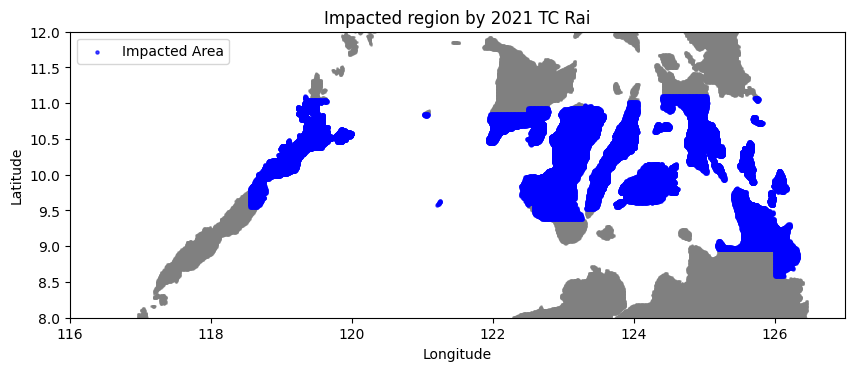

Static plot saved to rai_impact_plot.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
asset_gdf.plot(ax=ax, color='gray', markersize=1, alpha=0.5)
impacted_assets.plot(ax=ax, color='blue', markersize=5, alpha=0.7, label='Impacted Area')
plt.legend()
plt.title('Impacted region by 2021 TC Rai')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
ax.set_xlim(116, 127)
ax.set_ylim(8, 12)

output_plot = 'rai_impact_plot.png'
plt.savefig(output_plot)
plt.show()
print(f"Static plot saved to {output_plot}")

In [23]:
# Creating the visualization
def visualize(df):
    # Creating a figure and axis
    plt.figure(figsize=(12, 8))

    # Creating a scatter plot with color intensity based on population density
    scatter = plt.scatter(
        df['longitude'],
        df['latitude'],
        c=df['value'],
        s=10,
        cmap='viridis',
        norm=plt.Normalize(vmin=df['value'].min(), vmax=df['value'].quantile(0.95)),  # Cap at 95th percentile for better visualization
        alpha=0.6
    )

    # Adding a colorbar
    plt.colorbar(scatter, label='USD')

    # Setting labels and title
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Economic Value of physical assests in PHL')

    # Adding grid for better readability
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig("LitPop_pc_30arcsec_PHL.png")

    # Showing the plot
    plt.show()


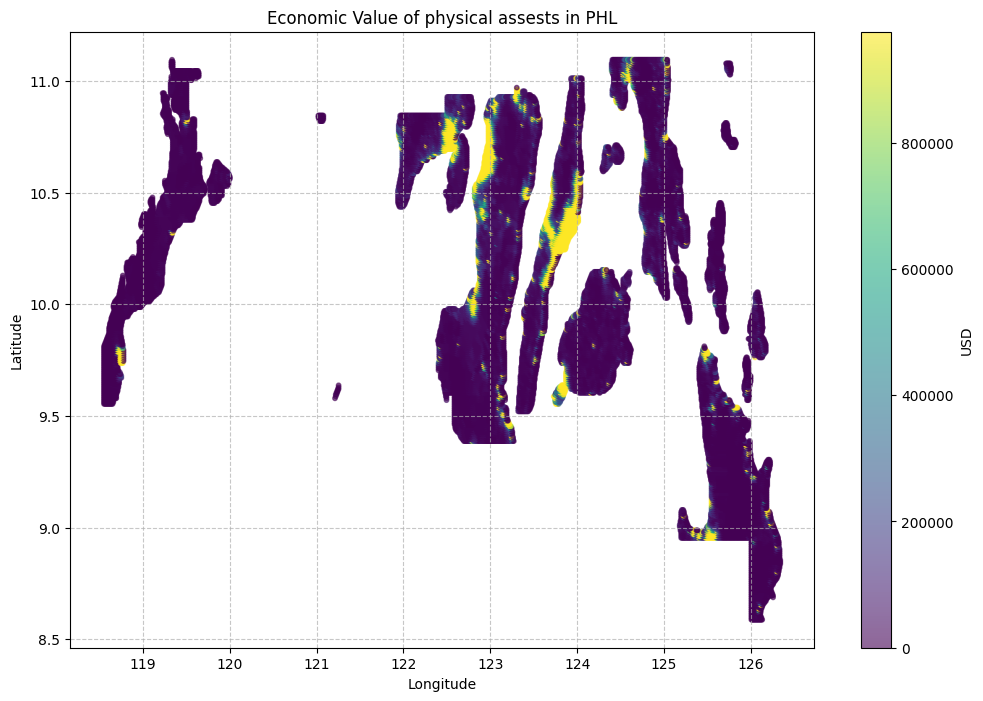

In [24]:
visualize(impacted_summary)